#Importing Libraries


In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

#Loading Dataset

In [224]:
url = "https://raw.githubusercontent.com/Nithinshibu07/Customer-Churn-Prediction/main/data/raw/Telco_customer_churn.xlsx"
df=pd.read_excel(url)


In [225]:
pd.set_option('display.max_columns', None)

In [226]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#Data Understanding

In [227]:
print("Shape of dataset -",df.shape)

Shape of dataset - (7043, 33)


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [229]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


#Missing Values Analysis

In [230]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
Churn Reason,5174


In [231]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

,0
Churn Reason,73.463013


#Duplicate Records

In [232]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


# Exploratory Data Analysis (EDA)


###Churn Distribution

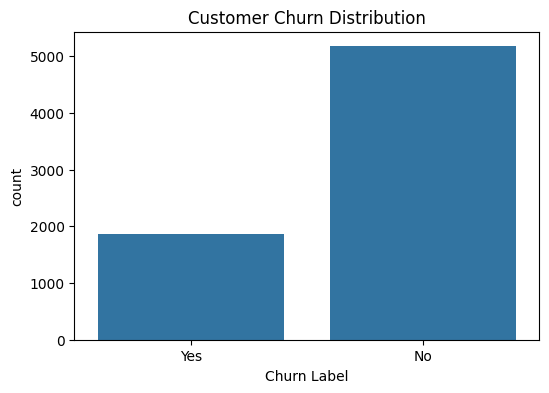

In [233]:


plt.figure(figsize=(6,4))

sns.countplot(x="Churn Label",data=df)

plt.title("Customer Churn Distribution")
plt.show()

##Churn Percentage Distribution

In [234]:
churn_percentage = round( df["Churn Label"].value_counts(normalize=True)*100,2
)

churn_percentage

,proportion
Churn Label,
No,73.46
Yes,26.54


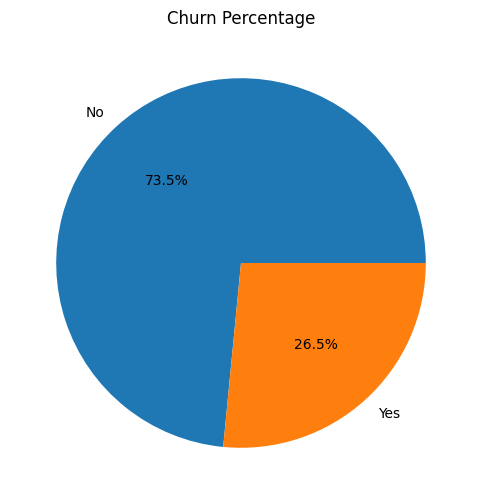

In [235]:
plt.figure(figsize=(6,6))

df["Churn Label"].value_counts().plot(kind="pie",
  autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

In [236]:
num_cols = ["Tenure Months","Monthly Charges","Total Charges","CLTV"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


## Tenure Analysis


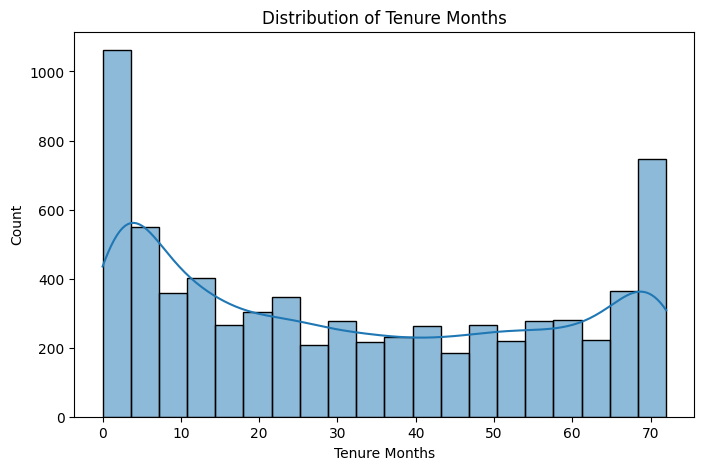

In [237]:
plt.figure(figsize=(8,5))

sns.histplot(df["Tenure Months"],bins=20,kde=True)

plt.title("Distribution of Tenure Months")
plt.show()

## Monthly Charges Analysis

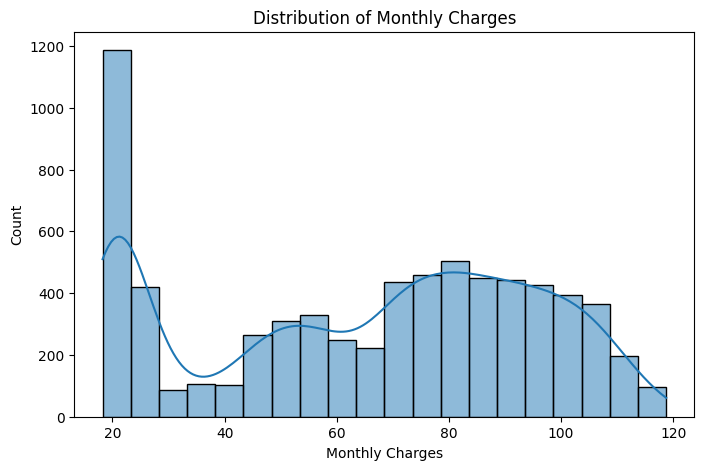

In [238]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly Charges"],bins=20,kde=True)

plt.title("Distribution of Monthly Charges")
plt.show()

## Tenure Months vs Churn

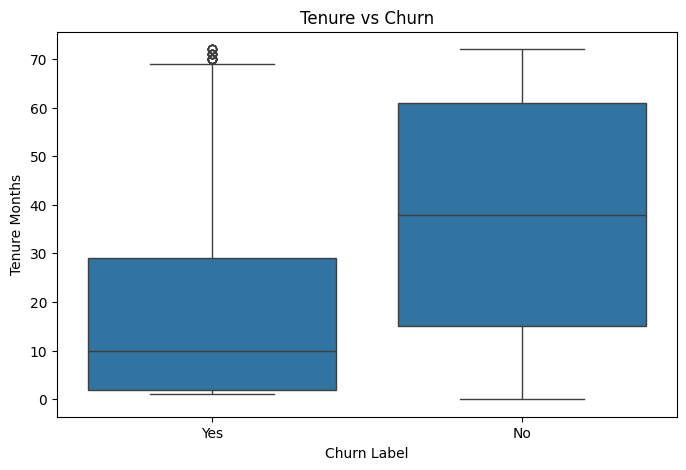

In [239]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="Tenure Months",data=df)

plt.title("Tenure vs Churn")
plt.show()

##Monthly Charges Analysis

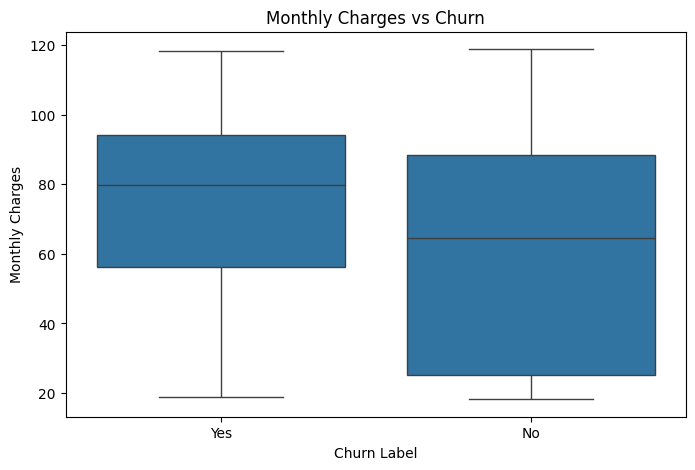

In [240]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="Monthly Charges",data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

## Customer Lifetime Value (CLTV) vs Churn

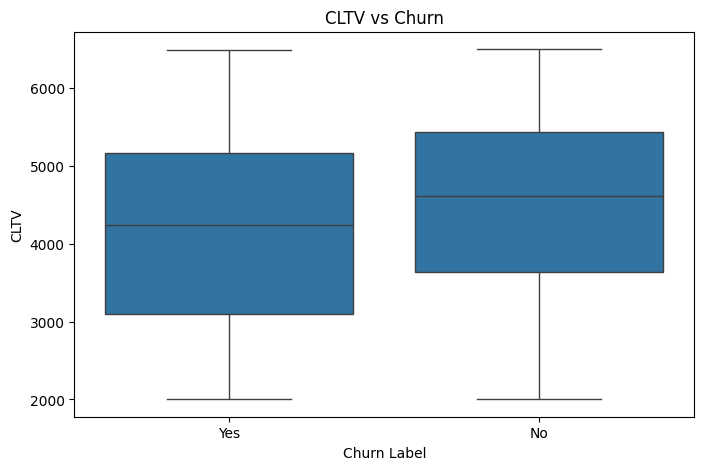

In [241]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="CLTV",data=df)

plt.title("CLTV vs Churn")
plt.show()

## Contract Type vs Churn

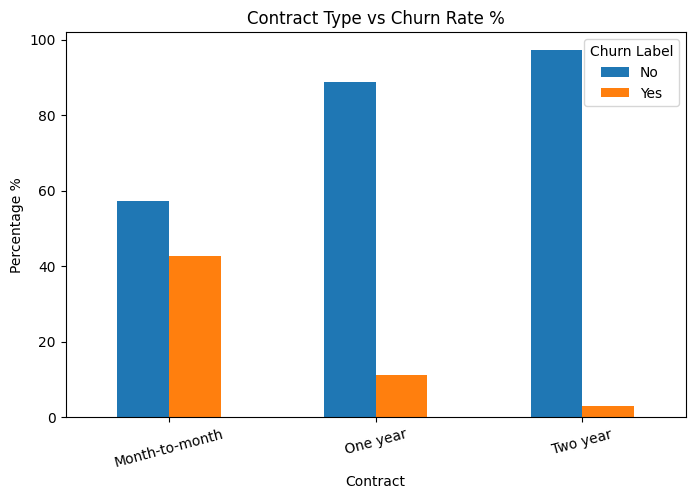

In [242]:
contract_churn = df.groupby('Contract')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
contract_churn.plot(kind='bar', figsize=(8,5))
plt.title('Contract Type vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

##Internet Service vs Churn

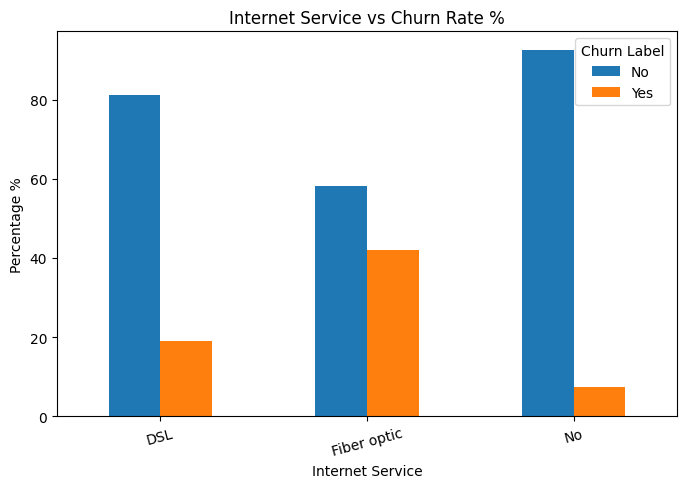

In [243]:
internet_churn = df.groupby('Internet Service')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
internet_churn.plot(kind='bar', figsize=(8,5))
plt.title('Internet Service vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

In [244]:
numerical_df = df.select_dtypes(include=np.number)

## converting Total Charges column to numeric

In [245]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df['Total Charges'] = df['Total Charges'].fillna(0)

## Correlation Analysis of Numerical Features

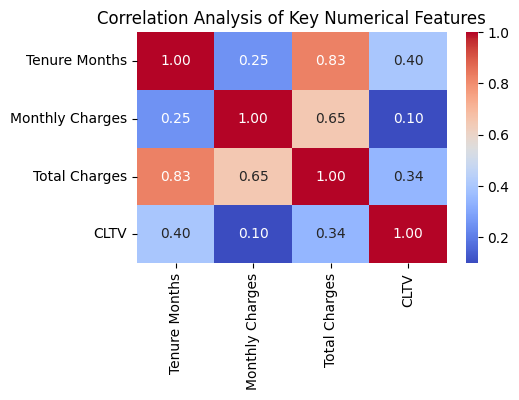

In [246]:
corr_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]


plt.figure(figsize=(5,3))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Analysis of Key Numerical Features")
plt.show()

#Data cleaning

In [247]:
data=df.copy()

In [248]:
# Drop irrelevant columns
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

data.drop(columns=drop_columns, inplace=True)

#remaining columns
print(data.columns)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='object')


In [249]:
#checking for missing values
data.isnull().sum()

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


#Feature engineering

## Feature 1 - Tenure group

In [250]:
data["Tenure Group"] = pd.cut(data["Tenure Months"],bins=[0,12,24,48,72],
    labels=["New","Growing","Established","Loyal"]
)

In [251]:
data["Tenure Group"].value_counts()

,count
Tenure Group,
Loyal,2239
New,2175
Established,1594
Growing,1024


## Feature 2 - Total Service Count

In [252]:
service_columns = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

data["Service Count"] = (
    data[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

In [253]:
data["Service Count"].describe()

,Service Count
count,7043.000000
mean,3.362914
std,2.062031
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


## Feature 3 - Auto Payment

In [254]:
data["Auto Payment"] = (
    data["Payment Method"]
    .str.contains("automatic", case=False)
    .astype(int)
)

## Feature 4 - Security Bundle

In [255]:
data["Security Bundle"] = (
    (
        (data["Online Security"] == "Yes") &
        (data["Tech Support"] == "Yes")
    )
).astype(int)

In [256]:
data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Tenure Group,Service Count,Auto Payment,Security Bundle
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,3,0,0
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,1,0,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,New,5,0,0
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,Established,6,0,0
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,Loyal,6,1,0


#Data Preprocessing

####Label encoding of Target Variable

In [257]:

data["Churn Label"] = data["Churn Label"].map({ "Yes": 1, "No": 0})
data["Churn Label"].value_counts()

,count
Churn Label,
0,5174
1,1869


##Prepare Features and Target

In [258]:
X = data.drop("Churn Label", axis=1)

y = data["Churn Label"]

In [259]:
y.value_counts()

,count
Churn Label,
0,5174
1,1869


##Train-Test Split

In [260]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 23)
(1409, 23)


##Handle "No Internet Service" and "No Phone Service"

In [261]:
replace_dict = {
    "No internet service": "No",
    "No phone service": "No"
}

X_train = X_train.replace(replace_dict)
X_test = X_test.replace(replace_dict)

##Binary Encoding

In [262]:
#Binary Encoding

binary_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing"
]

In [263]:
#maping

binary_map = {
    "Male": 1,
    "Female": 0,
    "Yes": 1,
    "No": 0
}

for col in binary_cols:
    X_train[col] = X_train[col].replace(binary_map)
    X_test[col] = X_test[col].replace(binary_map)

/tmp/ipykernel_938/1304482253.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].replace(binary_map)
/tmp/ipykernel_938/1304482253.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[col] = X_test[col].replace(binary_map)


##One-Hot Encoding

In [264]:
#One-Hot Encoding

multi_cat_cols = [
    "Internet Service",
    "Contract",
    "Payment Method",
    "Tenure Group"
]

In [265]:
#Encode

X_train = pd.get_dummies(
    X_train,
    columns=multi_cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=multi_cat_cols,
    drop_first=True
)

In [266]:
#Align Train and Test Columns

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [267]:
print(X_train.shape)
print(X_test.shape)

(5634, 29)
(1409, 29)


##Scale Numerical Features

In [268]:
#Scale Numerical Features

numerical_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Service Count"
]

In [269]:
#Standard Scaling

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [270]:
X_train

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Monthly Charges,Total Charges,Service Count,Auto Payment,Security Bundle,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group_Growing,Tenure Group_Established,Tenure Group_Loyal
4626,1,0,0,0,0.102371,0,0,0,0,1,0,1,1,0,-0.521976,-0.262257,-0.184954,0,0,False,False,False,False,False,True,False,False,True,False
4192,1,0,1,1,-0.711743,1,0,1,0,0,0,0,0,0,0.337478,-0.503635,-0.667823,0,0,True,False,False,False,False,False,True,True,False,False
5457,1,0,1,1,-0.793155,0,0,1,1,0,1,0,0,0,-0.809013,-0.749883,-0.184954,0,1,False,False,False,True,False,False,True,True,False,False
4717,0,0,1,0,-0.263980,1,0,0,1,1,0,1,1,1,0.284384,-0.172722,0.780784,1,0,False,False,False,True,True,False,False,False,True,False
4673,1,0,1,1,-1.281624,1,0,0,0,0,0,0,0,0,-0.676279,-0.989374,-1.150692,0,0,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6507,0,0,1,0,1.567778,1,1,0,1,1,1,1,1,0,1.470695,2.373129,1.746522,0,0,True,False,False,True,False,True,False,False,False,True
1646,1,0,0,0,-1.240918,1,0,0,0,0,0,0,0,0,-0.626504,-0.973665,-1.150692,1,0,False,False,False,False,False,False,False,False,False,False
1222,0,1,0,0,-0.304686,1,1,1,1,0,0,1,1,1,1.256662,0.158344,1.263653,0,0,True,False,False,False,False,False,True,False,True,False
3870,0,0,1,0,-0.345392,1,0,0,0,0,0,0,0,0,-1.477661,-0.797075,-1.150692,1,0,False,True,True,False,True,False,False,True,False,False


##Handle Class Imbalance Using SMOTE

In [271]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [272]:
print(y_train_smote.value_counts())

Churn Label
0    4139
1    4139
Name: count, dtype: int64


In [273]:
print("Training Shape:", X_train_smote.shape)
print("Testing Shape :", X_test.shape)

print("\nMissing Values in Train:")
print(X_train_smote.isnull().sum().sum())

print("\nMissing Values in Test:")
print(X_test.isnull().sum().sum())

Training Shape: (8278, 29)
Testing Shape : (1409, 29)

Missing Values in Train:
0

Missing Values in Test:
0


In [274]:
#Feature Matrix Overview

print("Number of Features:", X_train_smote.shape[1])

print("\nFeature Names:")
print(X_train_smote.columns.tolist())

Number of Features: 29

Feature Names:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Service Count', 'Auto Payment', 'Security Bundle', 'Internet Service_Fiber optic', 'Internet Service_No', 'Contract_One year', 'Contract_Two year', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Tenure Group_Growing', 'Tenure Group_Established', 'Tenure Group_Loyal']


##Class Distribution After SMOTE

In [275]:
y_train_smote.value_counts()

,count
Churn Label,
0,4139
1,4139


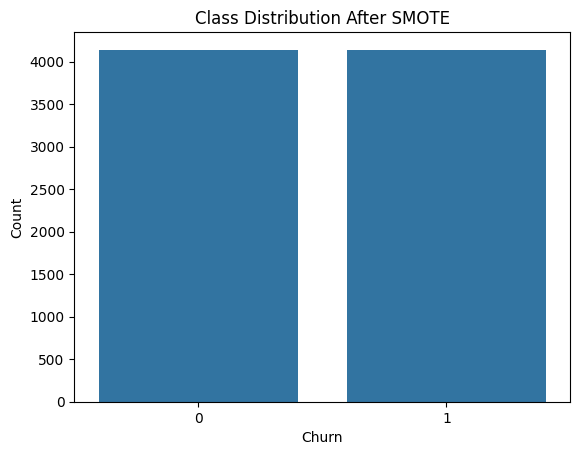

In [276]:

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

# Model Development and Evaluation

## Cross-Validation Setup

In [277]:
#Logistic Regression Cross Validation

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_scores = cross_val_score(
    lr_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print("Logistic Regression F1 Scores:")
print(lr_scores)

lr_f1 = lr_scores.mean()

print("\nMean F1 Score:", round(lr_f1,4))

Logistic Regression F1 Scores:
[0.74367294 0.77175284 0.87679083 0.85876347 0.84862127]

Mean F1 Score: 0.8199


In [278]:
#Random Forest Cross Validation
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_scores = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print("Random Forest F1 Scores:")
print(rf_scores)

rf_f1 = rf_scores.mean()

print("\nMean F1 Score:", round(rf_f1,4))

Random Forest F1 Scores:
[0.81289507 0.8170581  0.90340909 0.87892377 0.87325516]

Mean F1 Score: 0.8571


In [279]:
#LightGBM Cross Validation

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1
)

lgbm_scores = cross_val_score(
    lgbm_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print("LightGBM F1 Scores:")
print(lgbm_scores)

lgbm_f1 = lgbm_scores.mean()

print("\nMean F1 Score:", round(lgbm_f1,4))


LightGBM F1 Scores:
[0.75311067 0.78349206 0.89841986 0.88320356 0.87230514]

Mean F1 Score: 0.8381


In [287]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_scores = cross_val_score(
    xgb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="f1"
)

print("XGBoost F1 Scores:")
print(xgb_scores)

xgb_f1 = xgb_scores.mean()

print("\nMean F1 Score:", round(xgb_f1, 4))

XGBoost F1 Scores:
[0.76705277 0.7830487  0.89662921 0.87506941 0.86507496]

Mean F1 Score: 0.8374


In [288]:
#model comparison
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
        "XGBoost"
    ],
    "CV F1 Score":[
        lr_f1,
        rf_f1,
        lgbm_f1,
        xgb_f1
    ]
})

results = results.sort_values(
    by="CV F1 Score",
    ascending=False
)

results

,Model,CV F1 Score
1,Random Forest,0.857108
2,LightGBM,0.838106
3,XGBoost,0.837375
0,Logistic Regression,0.819920


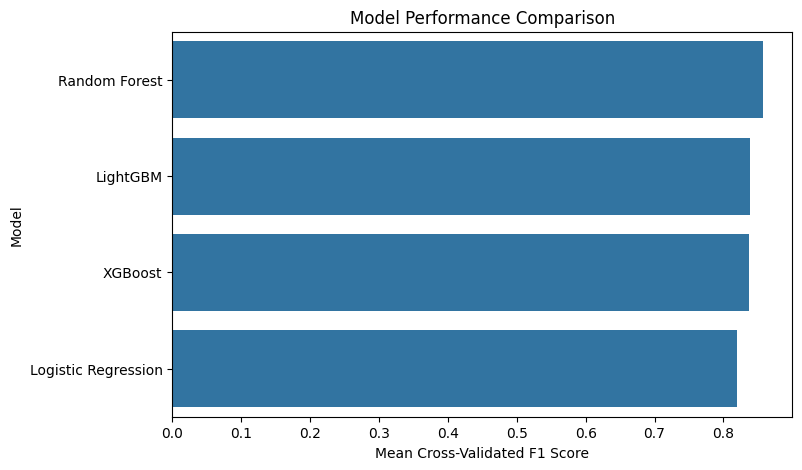

In [289]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="CV F1 Score",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("Mean Cross-Validated F1 Score")
plt.ylabel("Model")

plt.show()

In [283]:
print(
    "Random Forest achieved the highest "
    "cross-validated F1 Score and was "
    "selected as the final model."
)

Random Forest achieved the highest cross-validated F1 Score and was selected as the final model.


In [284]:
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=200, random_state=42)